<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/09_HernandezAlvaro_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Secuencias (NLP): Transformer Encoder en IMDB**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 28 de abril de 2026




## **Objetivo**
Construir un clasificador de sentimiento (positivo/negativo) en IMDB usando un bloque tipo Transformer Encoder (Self-Attention o Multi-Head Attention).

**Dataset**

`tensorflow.keras.datasets.imdb` (25k train / 25k test).
Usar `num_words=20000, longitud fija MAX_LEN=200`.

**Pasos**

1. Carga y preprocesamiento

2.	Modelo (baseline + Transformer)
*	Baseline: Embedding + GlobalAveragePooling + Dense.
*	Transformer: Embedding + PositionalEmbedding + MultiHeadAttention + (opcional) FFN + Pooling + Dense.

3.	Métricas mínimas: accuracy en validación y prueba; curva loss/acc.
Entregables (parte 1)
* Notebook con: preparación, modelos, curvas y resultados.
* Tabla comparativa (baseline vs self-Attention vs MultiHeadAttention).


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

VOCAB_SIZE = 20000
MAX_LEN = 200

# Carga de datos
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

# split de validación
VAL_SPLIT = 0.15
n_val = int(len(x_train) * VAL_SPLIT)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_trn, y_trn = x_train[n_val:], y_train[n_val:]

In [2]:
EMB_DIM = 128
BATCH   = 64

# Capa de Embeddings + Posición
class PositionalEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token = layers.Embedding(vocab_size, embed_dim)
        self.pos   = layers.Embedding(max_len, embed_dim)
        self.max_len = max_len
    def call(self, x):
        positions = tf.range(0, self.max_len)
        return self.token(x) + self.pos(positions)

# Baseline (rápido)
def build_baseline():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMB_DIM)(inp)
    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile("adam", "binary_crossentropy", metrics=["accuracy"])
    return m

# Transformer simple (solo atención o MHA)
def build_transformer():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)

    x = layers.Attention()([x, x])   #Self-att
# x = layers.MultiHeadAttention(num_heads=4, key_dim=EMB_DIM//4)(x, x)   # MultiHA

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(1e-3), "binary_crossentropy", metrics=["accuracy"])
    return m

baseline = build_baseline()
tx = build_transformer()

print("Baseline model training: ")

hist_base = baseline.fit(x_trn, y_trn, validation_data=(x_val, y_val),
                         epochs=30, batch_size=BATCH, verbose=2)

print("Attention model training: ")
hist_tx   = tx.fit(x_trn, y_trn, validation_data=(x_val, y_val),
                   epochs=30, batch_size=BATCH, verbose=2)

test_base = baseline.evaluate(x_test, y_test, verbose=0)
test_tx   = tx.evaluate(x_test, y_test, verbose=0)
print(f"Baseline  Test acc: {test_base[1]:.4f}")
print(f"Attention Test acc: {test_tx[1]:.4f}")


Baseline model training: 
Epoch 1/30
333/333 - 4s - 12ms/step - accuracy: 0.7232 - loss: 0.5870 - val_accuracy: 0.8181 - val_loss: 0.4537
Epoch 2/30
333/333 - 1s - 3ms/step - accuracy: 0.8577 - loss: 0.3725 - val_accuracy: 0.8629 - val_loss: 0.3488
Epoch 3/30
333/333 - 1s - 3ms/step - accuracy: 0.8916 - loss: 0.2859 - val_accuracy: 0.8747 - val_loss: 0.3067
Epoch 4/30
333/333 - 1s - 3ms/step - accuracy: 0.9120 - loss: 0.2364 - val_accuracy: 0.8811 - val_loss: 0.2926
Epoch 5/30
333/333 - 1s - 3ms/step - accuracy: 0.9276 - loss: 0.2023 - val_accuracy: 0.8864 - val_loss: 0.2773
Epoch 6/30
333/333 - 1s - 3ms/step - accuracy: 0.9391 - loss: 0.1756 - val_accuracy: 0.8856 - val_loss: 0.2733
Epoch 7/30
333/333 - 1s - 3ms/step - accuracy: 0.9504 - loss: 0.1509 - val_accuracy: 0.8848 - val_loss: 0.2813
Epoch 8/30
333/333 - 1s - 4ms/step - accuracy: 0.9575 - loss: 0.1338 - val_accuracy: 0.8845 - val_loss: 0.2835
Epoch 9/30
333/333 - 1s - 4ms/step - accuracy: 0.9612 - loss: 0.1230 - val_accuracy: 

Modificar el programa para implementar un bloque Transformers (no solo atención), empleando las siguientes funciones:

In [3]:
# Bloque Transformer (self-attn simple ó multi-head)
# -------------------------
def transformer_block(x, use_multihead=True):
    # x: (batch, seq_len, EMB_DIM)
    if use_multihead:
        attn_out = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=EMB_DIM // 4
        )(x, x)  # self-attention
    else:
        # Self-attention simple con una sola "cabeza"
        attn_out = layers.Attention()([x, x])  # (batch, seq_len, EMB_DIM)

    # Residual + LayerNorm
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Pequeño feed-forward
    ff = layers.Dense(EMB_DIM * 2, activation="relu")(x)
    ff = layers.Dense(EMB_DIM)(ff)

    # Otro residual + LayerNorm
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

# -------------------------
# Transformer con self-attention simple (sin MultiHead)
# -------------------------
def build_transformer_selfatt():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=False)   # self-attention
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# -------------------------
# Transformer con MultiHeadAttention
# -------------------------
def build_transformer_mha():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=True)    # multi-head attention
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# -------------------------
# Entrenamiento de los 2 modelos
# -------------------------
selfatt_tx = build_transformer_selfatt()
mha_tx     = build_transformer_mha()

print("\n=== Entrenando Transformer (Self-Attention) ===")
hist_self = selfatt_tx.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=BATCH,
    verbose=2
)

print("\n=== Entrenando Transformer (MultiHeadAttention) ===")
hist_mha = mha_tx.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=BATCH,
    verbose=2
)

# -------------------------
# Evaluación
# -------------------------
test_self = selfatt_tx.evaluate(x_test, y_test, verbose=0)
test_mha  = mha_tx.evaluate(x_test, y_test, verbose=0)

print("\n=== RESULTADOS EN TEST ===")
print(f"Transformer Self-Attn    -> acc: {test_self[1]:.4f}")
print(f"Transformer Multi-Head   -> acc: {test_mha[1]:.4f}")



=== Entrenando Transformer (Self-Attention) ===
Epoch 1/20
333/333 - 11s - 34ms/step - accuracy: 0.7952 - loss: 0.4356 - val_accuracy: 0.7472 - val_loss: 0.5389
Epoch 2/20
333/333 - 3s - 8ms/step - accuracy: 0.9066 - loss: 0.2390 - val_accuracy: 0.8723 - val_loss: 0.3040
Epoch 3/20
333/333 - 2s - 7ms/step - accuracy: 0.9400 - loss: 0.1634 - val_accuracy: 0.8771 - val_loss: 0.3225
Epoch 4/20
333/333 - 2s - 7ms/step - accuracy: 0.9590 - loss: 0.1180 - val_accuracy: 0.8373 - val_loss: 0.4502
Epoch 5/20
333/333 - 2s - 7ms/step - accuracy: 0.9702 - loss: 0.0836 - val_accuracy: 0.8168 - val_loss: 0.6611
Epoch 6/20
333/333 - 3s - 8ms/step - accuracy: 0.9698 - loss: 0.0846 - val_accuracy: 0.8728 - val_loss: 0.4141
Epoch 7/20
333/333 - 3s - 8ms/step - accuracy: 0.9866 - loss: 0.0447 - val_accuracy: 0.8560 - val_loss: 0.5102
Epoch 8/20
333/333 - 2s - 7ms/step - accuracy: 0.9901 - loss: 0.0339 - val_accuracy: 0.8613 - val_loss: 0.5368
Epoch 9/20
333/333 - 2s - 7ms/step - accuracy: 0.9910 - loss:

In [4]:
BATCH = 64
EPOCHS = 15

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modelo Transformer con Self-Attention (una cabeza)
selfatt_model = build_transformer_selfatt()
print("\n=== Entrenando Transformer (Self-Attention) ===")
hist_self = selfatt_model.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2
)

# Modelo Transformer con Multi-Head Attention
mha_model = build_transformer_mha()
print("\n=== Entrenando Transformer (MultiHeadAttention) ===")
hist_mha = mha_model.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2
)


=== Entrenando Transformer (Self-Attention) ===
Epoch 1/15
333/333 - 11s - 33ms/step - accuracy: 0.7963 - loss: 0.4293 - val_accuracy: 0.7933 - val_loss: 0.4216
Epoch 2/15
333/333 - 3s - 8ms/step - accuracy: 0.9056 - loss: 0.2381 - val_accuracy: 0.8525 - val_loss: 0.3617
Epoch 3/15
333/333 - 5s - 15ms/step - accuracy: 0.9375 - loss: 0.1699 - val_accuracy: 0.8640 - val_loss: 0.3214
Epoch 4/15
333/333 - 3s - 8ms/step - accuracy: 0.9554 - loss: 0.1221 - val_accuracy: 0.8747 - val_loss: 0.3362
Epoch 5/15
333/333 - 3s - 8ms/step - accuracy: 0.9701 - loss: 0.0888 - val_accuracy: 0.8555 - val_loss: 0.4416
Epoch 6/15
333/333 - 3s - 8ms/step - accuracy: 0.9770 - loss: 0.0701 - val_accuracy: 0.8499 - val_loss: 0.5238

=== Entrenando Transformer (MultiHeadAttention) ===
Epoch 1/15
333/333 - 15s - 44ms/step - accuracy: 0.8088 - loss: 0.4015 - val_accuracy: 0.8395 - val_loss: 0.3638
Epoch 2/15
333/333 - 4s - 13ms/step - accuracy: 0.9223 - loss: 0.1980 - val_accuracy: 0.8821 - val_loss: 0.2999
Epoc

In [9]:
test_self = selfatt_model.evaluate(x_test, y_test, verbose=0)
test_mha = mha_model.evaluate(x_test, y_test, verbose=0)

print("\n=== RESULTADOS EN TEST ===")
print(f"Baseline (GlobalAvgPool)                -> acc: {test_base[1]:.4f}")
print(f"Transformer Self-Attention (completo)   -> acc: {test_self[1]:.4f}")
print(f"Transformer Multi-Head Attention        -> acc: {test_mha[1]:.4f}")

# Tabla

df_results = pd.DataFrame({
    "Modelo": ["Baseline (GlobalAvgPool)", "Transformer Self-Attention", "Transformer Multi-Head"],
    "Test Accuracy": [test_base[1], test_self[1], test_mha[1]]
})

print("\nTabla Comparativa:")
print(df_results.to_string(index=False))


=== RESULTADOS EN TEST ===
Baseline (GlobalAvgPool)                -> acc: 0.8473
Transformer Self-Attention (completo)   -> acc: 0.8488
Transformer Multi-Head Attention        -> acc: 0.8706

Tabla Comparativa:
                    Modelo  Test Accuracy
  Baseline (GlobalAvgPool)        0.84732
Transformer Self-Attention        0.84880
    Transformer Multi-Head        0.87060


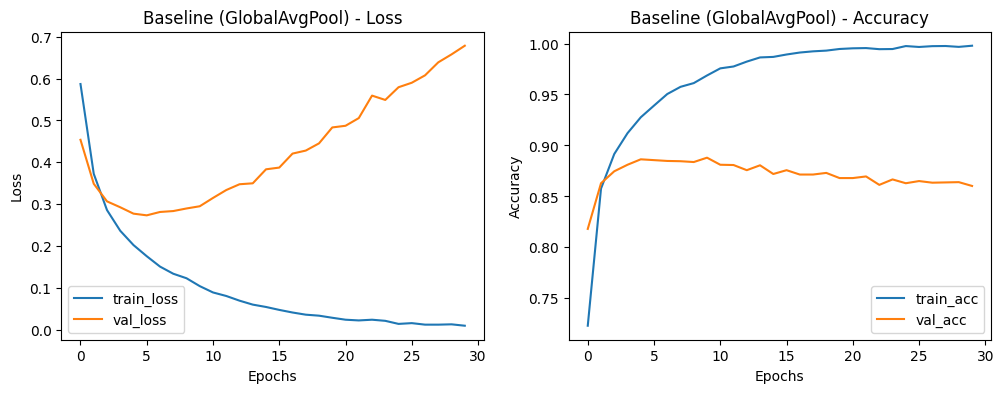

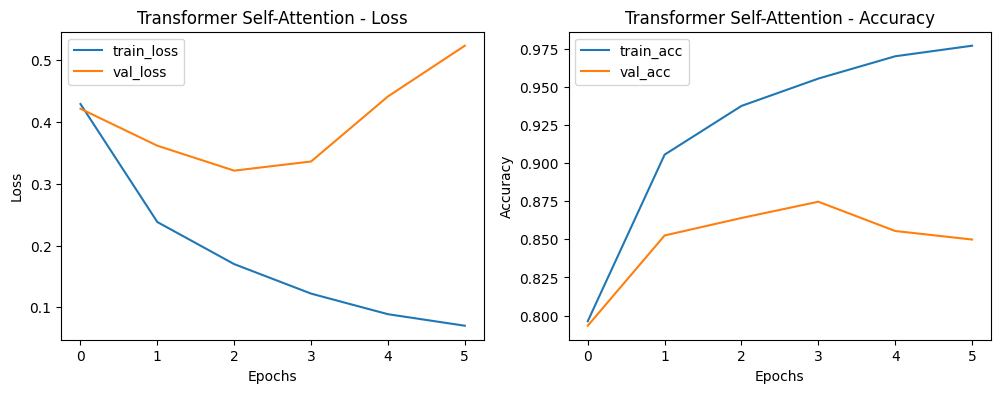

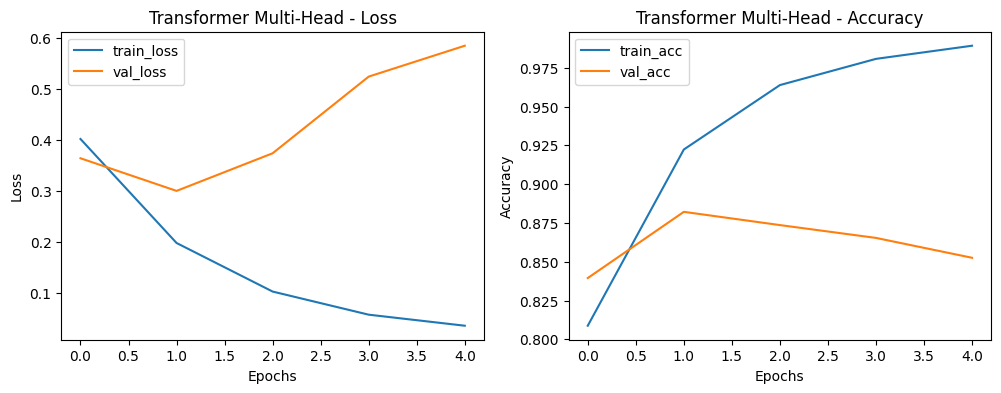

In [10]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    # Gráfica de Loss
    ax1.plot(history.history['loss'], label='train_loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Gráfica de Accuracy
    ax2.plot(history.history['accuracy'], label='train_acc')
    ax2.plot(history.history['val_accuracy'], label='val_acc')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.show()

# Graficamos los tres modelos
plot_history(hist_base, "Baseline (GlobalAvgPool)")
plot_history(hist_self, "Transformer Self-Attention")
plot_history(hist_mha, "Transformer Multi-Head")